## Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## Why this dataset matters

This dataset is historically important because it helped establish modern approaches for studying neural coding using:

- spike-triggered average (STA)
- spike-triggered covariance (STC)
- nonlinear receptive field estimation
- natural stimulus encoding models

It remains highly relevant today for comparing classical neuroscience methods with modern machine learning models such as GLMs, CNNs, and neural system identification networks.

Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.

For the `msq1D` white-noise experiments, the `.log` field `StiW` specifies the stimulus width on the display in centimeters. The viewing distance was 114 cm, so 1 cm corresponds to approximately 0.5° of visual angle. Since the stimulus contains 16 bars, the spatial width of each bar is `StiW / 16` cm (≈ `0.5 * StiW / 16` degrees). The stimulus coordinate system was aligned to each neuron's preferred orientation and direction.

When plotting STA/STC filters, label x-axis as:

Position (deg visual angle)

using StiW.

That makes the notebook publication-quality.

- imsq1D.mat = temporal sequence of bar patterns

From the dataset documentation:

msq1D.mat = 1D M-sequence stimulus with 16 bars, 32767 frames
imsq1D.mat = inverted M-sequence stimulus with 512 frames

This gives you:

X = stimulus matrix (known input)
y = spikes (neural output)

That is a supervised learning problem.

You can fit:

linear receptive fields
Poisson GLMs
CNNs
RNNs
temporal filters

## settings for the project

In [77]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import sys






In [78]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


DATA_ROOT=PROJECT_ROOT/'data'/'crcns-pvc2'
root =DATA_ROOT / "1D_white_noise/Spike_and_Log_Files"



from src.get_spikes import (fget_spk_python, retrieve_log, tori,
                            load_log_lines, numbers,
                            search_log)

from src.utiles import (is_it_complex, compute_sta, 
                        compute_r_estimate, gaussian_rate_convolution)

the first priority after isolating a neuron is to determine what kind of stimulus drives it best. The tuning run is therefore usually performed first as a calibration and characterization step.

For V1 neurons, especially in cat primary visual cortex, responses depend strongly on stimulus orientation, spatial frequency, position, contrast, and motion. If you do not know these preferences first, later experiments may be inefficient or even misleading.



In [79]:
cell_results = is_it_complex(root, plot=False)
simple_cells = {
    folder: result
    for folder, result in cell_results.items()
    if result["cell_type"] == "simple / linear-like"
}
simple_cells


Correcting spike file: 000512.d11atune.sa0 -> 000513.d11atune.sa0
Correcting spike file: 000802.c05atune.sa1 -> 000802.c05atune.sa0


{'000420.b02': {'file': '000420.b02atune.log',
  'relmod': 1.8052012990662298,
  'cell_type': 'simple / linear-like'},
 '010801.A.b01': {'file': '010801.A.b01dtune.log',
  'relmod': 1.1081355156101484,
  'cell_type': 'simple / linear-like'}}

In [80]:
COMPLEX_NEURON_PATH= root/'000413.b03'

LINEAR_NEURON_PATH=root/'000420.b02'

STIM_PATH  = DATA_ROOT/'1D_white_noise/Stimulus_Files/msq1D.mat'


filenames_complex = [
    
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]


filenames_linear=[
    '000420.b02bmsq1d.sa0',
    '000420.b02cmsq1d.sa0',
    '000420.b02dmsq1d.sa0',
    '000420.b02emsq1d.sa0',
    '000420.b02fmsq1d.sa0',
    '000420.b02gmsq1d.sa0',
    '000420.b02hmsq1d.sa0'

]


paths_comples_trials = [COMPLEX_NEURON_PATH / name for name in filenames_complex]
paths_linear_trial = [LINEAR_NEURON_PATH / name for name in filenames_linear]






In [81]:
msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1
T, N = msq1D_stim.shape
mean_stim=msq1D_stim.mean()

print(f'stimulus shape:{T,N}, stimulus mean={mean_stim}')


stimulus shape:(32767, 16), stimulus mean=3.051850947599719e-05


### neuron b03 of 2000

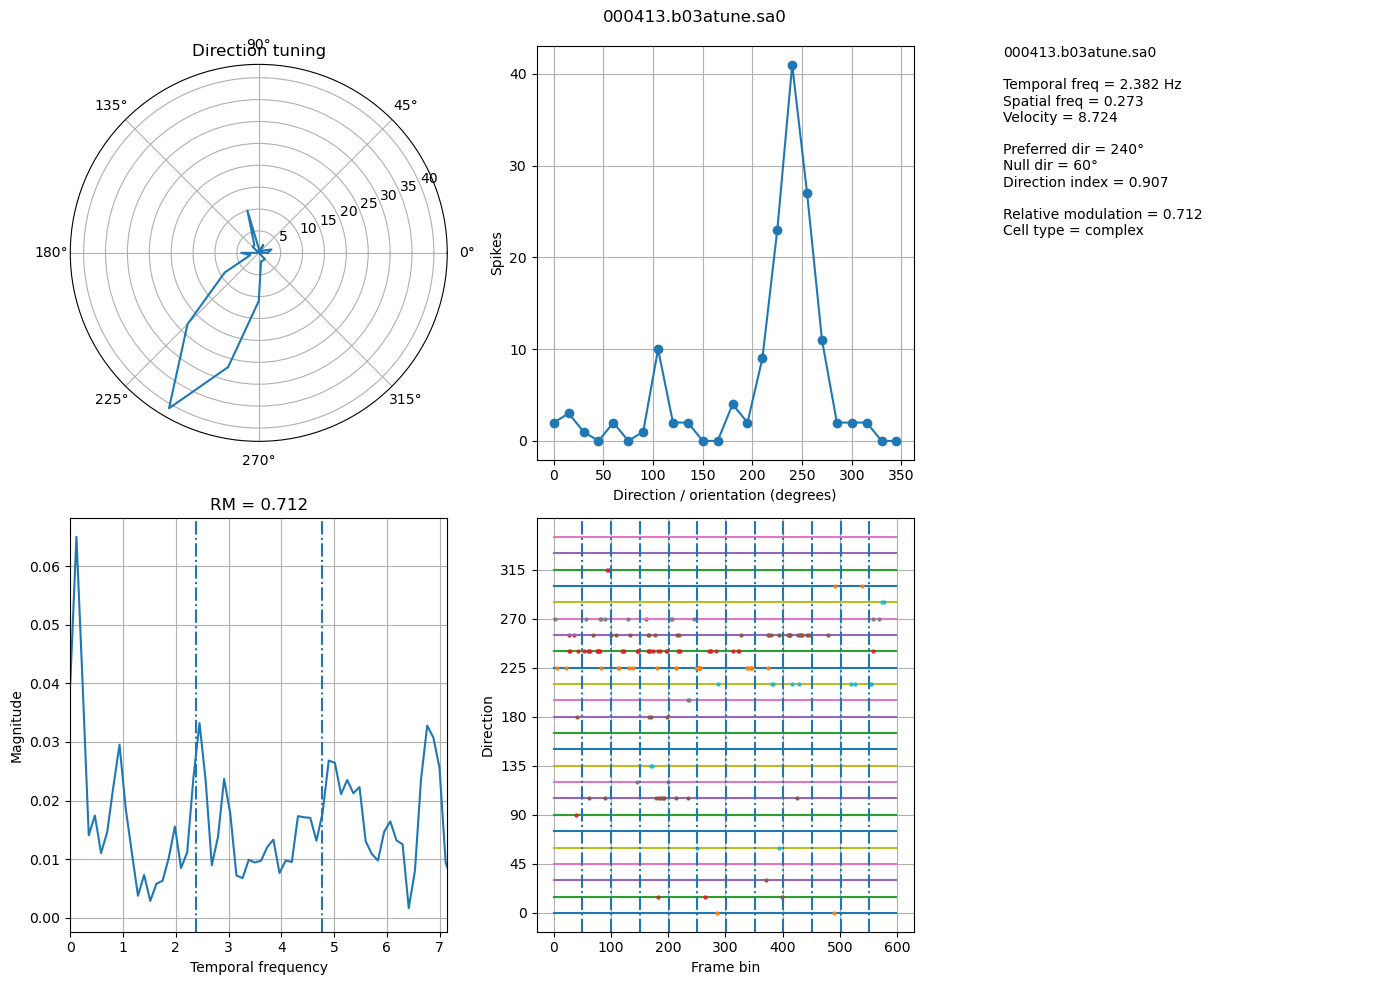

In [82]:
flog = retrieve_log(
    path=COMPLEX_NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)




In [83]:

for path in paths_comples_trials:




    log_lines         = load_log_lines(path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### neuron b02 of 2004

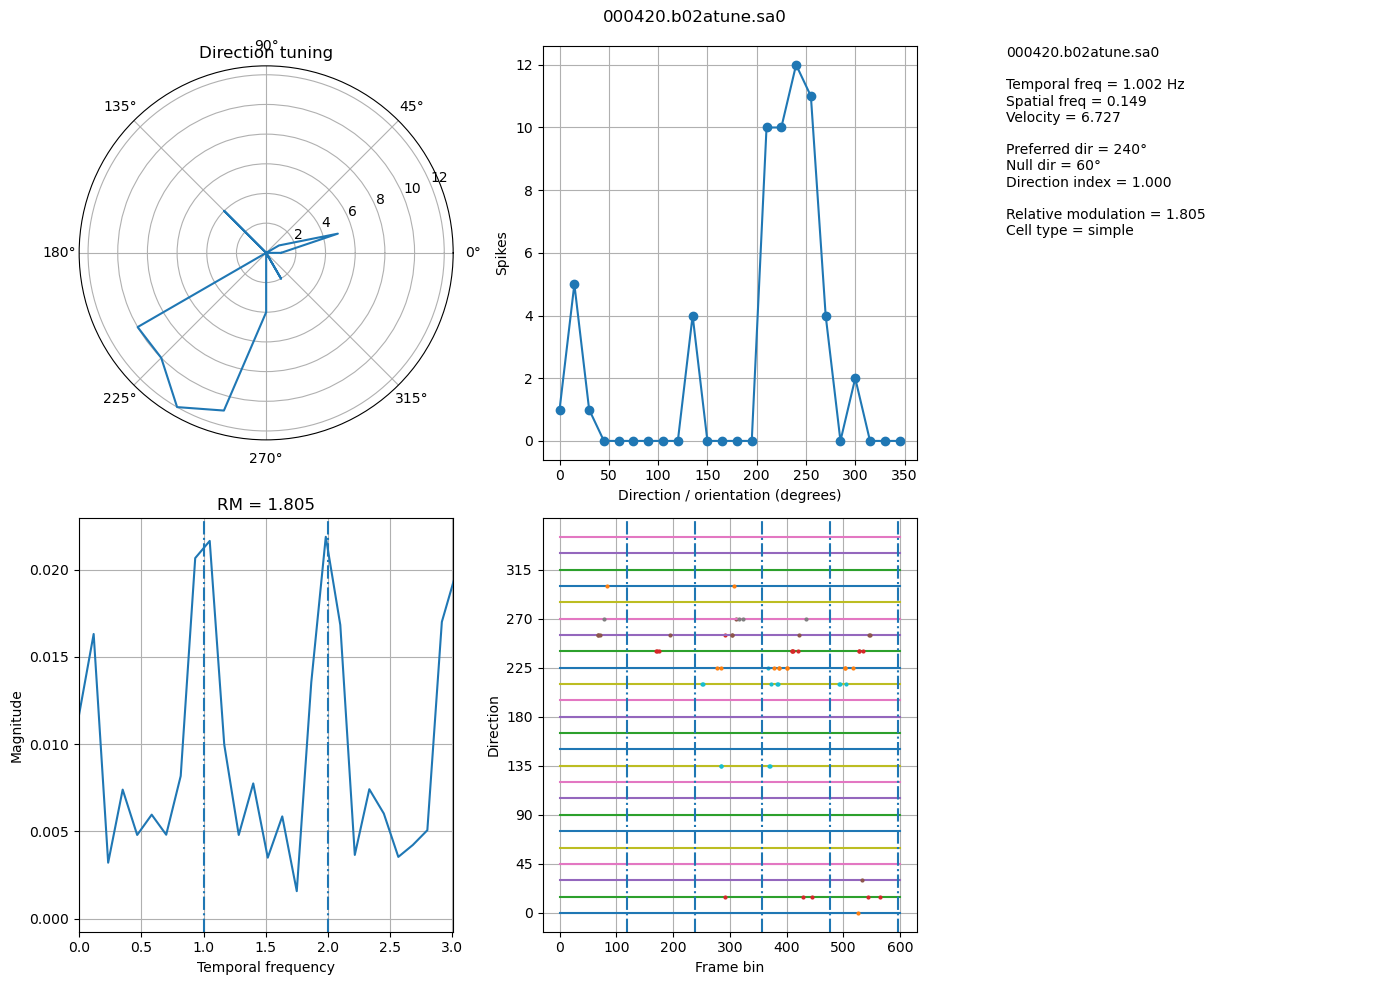

In [84]:
flog = retrieve_log(
    path=LINEAR_NEURON_PATH,
    filename="000420.b02atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)
paths = [LINEAR_NEURON_PATH / name for name in filenames_complex]


msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1




In [85]:
for path in paths_linear_trial:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines( path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### stimulus 

Text(0.5, 1.0, '1D white-noise stimulus: 3.0 s window')

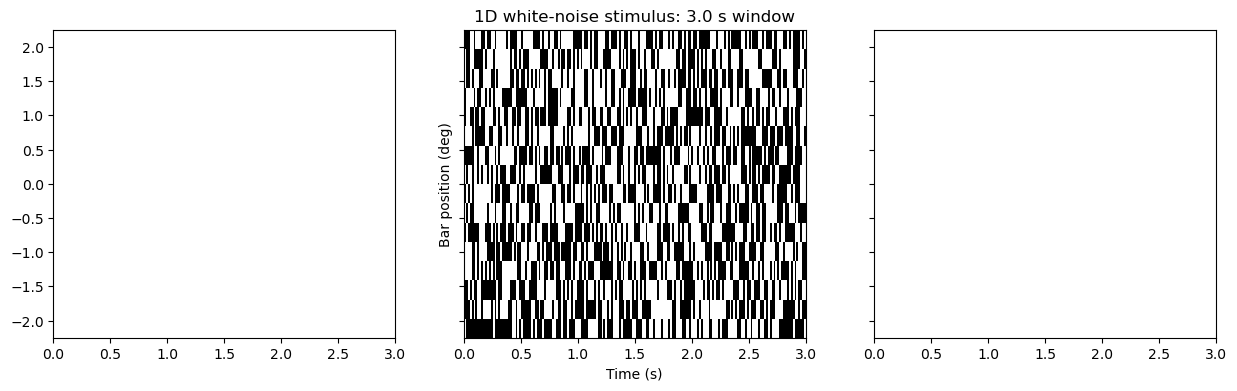

In [86]:
bar_positions = np.linspace(-2.25, 2.25, N)




t0 = 0.0
duration = 3.0

i0 = int(t0 * frame_rate)
i1 = int((t0 + duration) * frame_rate)

stim_window = msq1D_stim[i0:i1]




fig, axes = plt.subplots(
    1, 3,
    figsize=(5 * 3, 4),
    sharex=True,
    sharey=True
)





axes[1].imshow(
    stim_window.T,
    aspect="auto",
    cmap="gray",
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    extent=[t0, t0 + duration, bar_positions[0], bar_positions[-1]],
    origin="lower"
)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Bar position (deg)")
axes[1].set_title(f"1D white-noise stimulus: {duration:.1f} s window")

# simple cell

000420.b02bmsq1d.sa0
Spike count: 583
First 10 events: [  3914   3930  40481  42780  44460  44489  83092 115928 159197 166355]

000420.b02cmsq1d.sa0
Spike count: 645
First 10 events: [ 75726 102368 259150 262400 270362 309654 315127 316941 317004 333238]

000420.b02dmsq1d.sa0
Spike count: 645
First 10 events: [ 28666  34303 111487 140452 141307 146699 160683 187953 236980 241236]



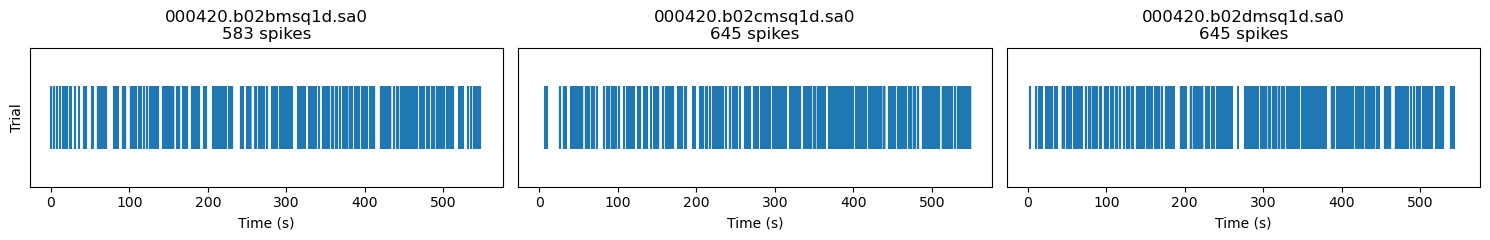

In [87]:
n_trials = 3

fig, axes = plt.subplots(
    1, n_trials,
    figsize=(5 * n_trials, 2.5),
    sharex=True,
    sharey=True
)

for ax, path in zip(axes, paths_linear_trial[:n_trials]):
    events, spike_times_sec, hdr = fget_spk_python(path)

    print(Path(path).name)
    print("Spike count:", len(events))
    print("First 10 events:", events[:10])
    print()

    ax.eventplot(
        spike_times_sec,
        lineoffsets=1,
        linelengths=0.8
    )

    ax.set_title(f"{Path(path).name}\n{len(events)} spikes")
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])

axes[0].set_ylabel("Trial")

plt.tight_layout()
plt.show()

### Spike-Triggered Average (STA)

Spike-triggered averaging estimates a neuron’s stimulus-dependent receptive field by averaging the stimulus preceding spikes. To assess whether this estimated receptive field is stable rather than dominated by sampling noise, the data can be split into two independent halves and the resulting estimates compared by correlation. A high split-half correlation indicates reliable structure across repeated measurements, whereas a low correlation suggests that the estimate is noisy, weak, or poorly captured by the assumed linear model.

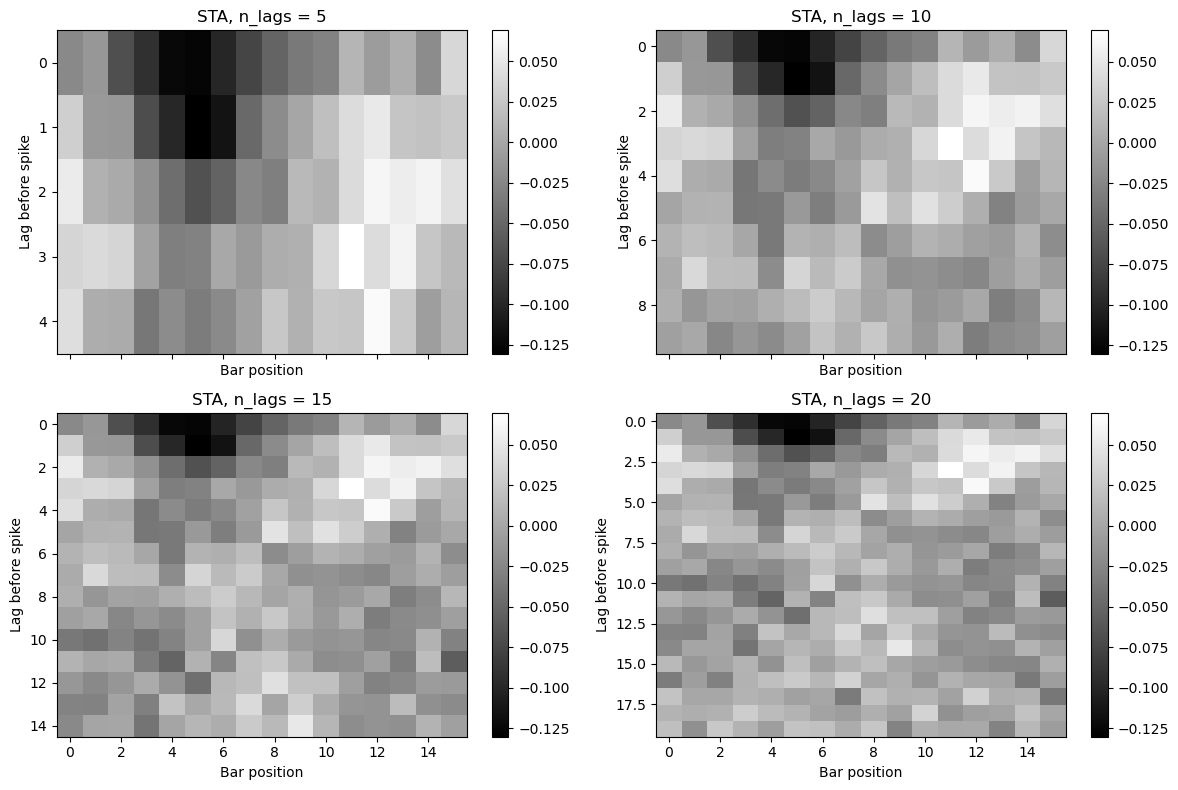

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True
)

axes = axes.ravel()

for ax, n_lags in zip(axes, [5, 10, 15, 20]):
    sta_full, n_spikes = compute_sta(
        paths_linear_trial,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate
    )

    im = ax.imshow(sta_full, aspect="auto", cmap="gray")
    ax.set_title(f"STA, n_lags = {n_lags}")
    ax.set_xlabel("Bar position")
    ax.set_ylabel("Lag before spike")

    fig.colorbar(im, ax=ax)

    

plt.tight_layout()
plt.show()

### underdtand the 33 lag, why is it always the same 

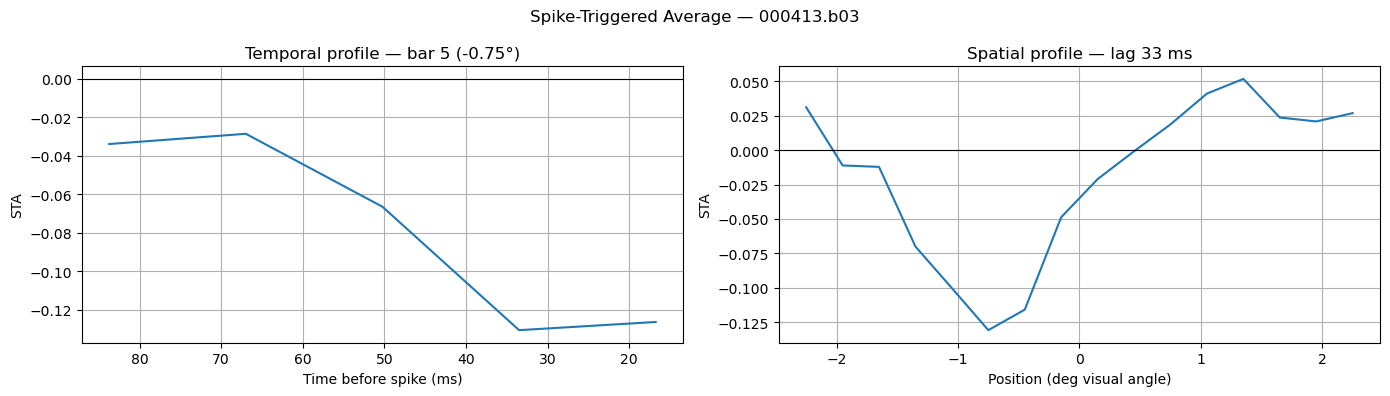

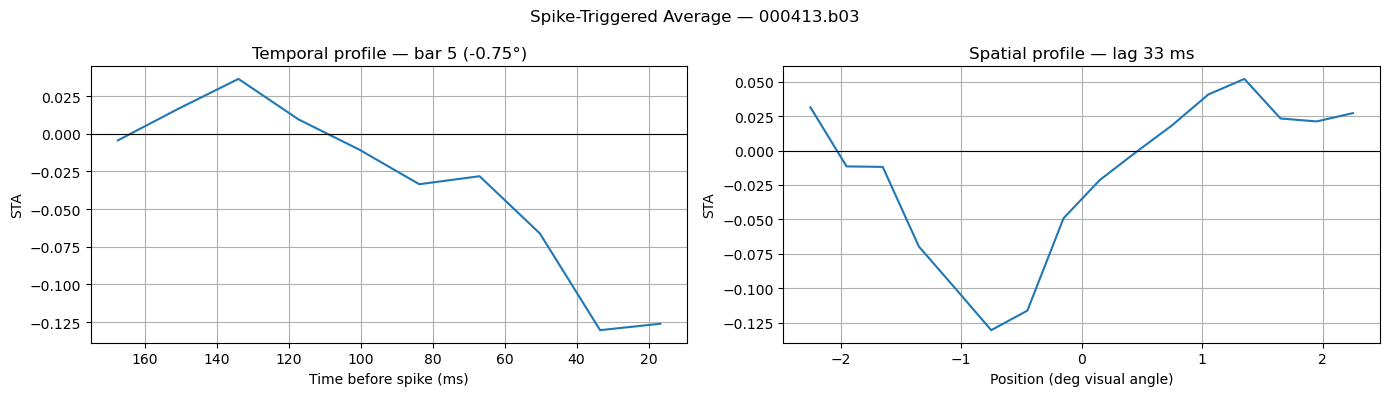

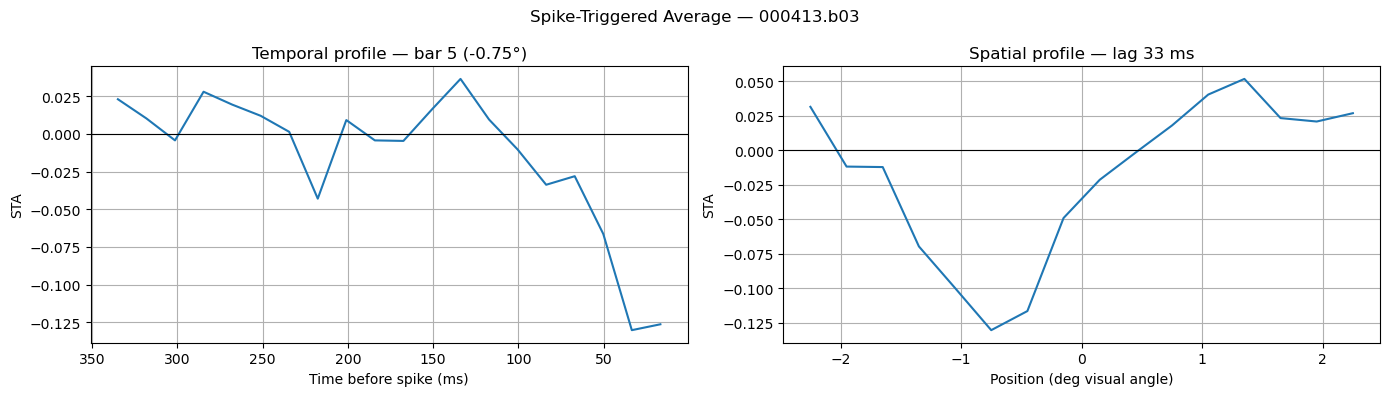

In [96]:
for n_lags in [5, 10,20]:
    sta_full, n_spikes = compute_sta(
        paths_linear_trial,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate
    )

    bar_positions = np.linspace(-sti_w_deg / 2, sti_w_deg / 2, 16)   # bar centres in degrees
    lags_ms       = np.arange(1, n_lags + 1) / frame_rate * 1000      # ms before spike

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Spike-Triggered Average — 000413.b03')


    # Temporal profile at peak spatial position
    ax = axes[0]
    peak_bar = int(np.abs(sta_full).max(axis=0).argmax())
    ax.plot(lags_ms, sta_full[:, peak_bar])
    ax.axhline(0, color='k', linewidth=0.8)
    ax.invert_xaxis()
    ax.set_xlabel('Time before spike (ms)')
    ax.set_ylabel('STA')
    ax.set_title(f'Temporal profile — bar {peak_bar} ({bar_positions[peak_bar]:.2f}°)')
    ax.grid(True)

    # Spatial profile at peak lag
    ax = axes[1]
    peak_lag = int(np.abs(sta_full).max(axis=1).argmax())
    ax.plot(bar_positions, sta_full[peak_lag])
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_xlabel('Position (deg visual angle)')
    ax.set_ylabel('STA')
    ax.set_title(f'Spatial profile — lag {lags_ms[peak_lag]:.0f} ms')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [76]:
n_lags=10

In [93]:
rng = np.random.default_rng(0)

n_repeats = 100
split_corrs = []

for _ in range(n_repeats):
    shuffled = list(paths_linear_trial)
    rng.shuffle(shuffled)

    half = len(shuffled) // 2
    trial_a = shuffled[:half]
    trial_b = shuffled[half:]

    sta_a, n_a = compute_sta(
        trial_a,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate
    )

    sta_b, n_b = compute_sta(
        trial_b,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate
    )

    r = np.corrcoef(sta_a.ravel(), sta_b.ravel())[0, 1]
    split_corrs.append(r)

split_corrs = np.array(split_corrs)

split_half_mean = split_corrs.mean()
split_half_std = split_corrs.std()

split_half_mean, split_half_std

(0.6620434534387301, 0.04063408476597095)

In [94]:
sta_full, n_spikes = compute_sta(
                                    paths_linear_trial,
                                    msq1D_stim,
                                    n_lags=n_lags,
                                    frame_rate=frame_rate
                                )
print(f'STA shape: {sta_full.shape}  (lags × bars)')


STA shape: (10, 16)  (lags × bars)


In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d





def bin_spikes_to_frames(spike_times_sec, T, frame_rate, stim_onset_sec=0.0):
    spk_stim_sec = spike_times_sec - stim_onset_sec
    edges = np.arange(T + 1) / frame_rate
    counts, _ = np.histogram(spk_stim_sec, bins=edges)
    return counts


def smooth_frame_counts(counts, frame_rate, sigma_sec=0.05):
    sigma_frames = sigma_sec * frame_rate
    return gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_frames,
        mode="constant"
    ) * frame_rate





# ---------- prepare stimulus ----------







# ---------- 2. split-half reliability ----------


split_corr = safe_corr(sta_a.ravel(), sta_b.ravel())

print("\nSplit-half reliability")
print("Spikes half A:", n_a)
print("Spikes half B:", n_b)
print("STA correlation:", split_corr)


# ---------- 3. leave-one-trial-out prediction ----------

loo_corrs = []

for test_idx in range(len(paths_linear_trial,)):
    train_files = [f for i, f in enumerate(paths_linear_trial,) if i != test_idx]
    test_file = paths_linear_trial[test_idx]

    sta_train, n_train = compute_sta(
        train_files,
        stim_centered,
        n_lags=n_lags,
        frame_rate=frame_rate,
        
    )

    r_est = compute_r_estimate(stim_centered, sta_train)

    _, spk_sec_test, _ = fget_spk_python(test_file)

    spike_counts = bin_spikes_to_frames(
        spk_sec_test,
        T=T,
        frame_rate=frame_rate,
        
    )

    rate_test = smooth_frame_counts(
        spike_counts,
        frame_rate=frame_rate,
        sigma_sec=0.05
    )

    corr = safe_corr(r_est, rate_test)
    loo_corrs.append(corr)

    print(f"\nHeld-out trial {test_idx + 1}")
    print("Train spikes:", n_train)
    print("Test spikes:", len(spk_sec_test))
    print("Prediction correlation:", corr)

loo_corrs = np.array(loo_corrs)

print("\nLeave-one-trial-out summary")
print("Mean correlation:", np.nanmean(loo_corrs))
print("Std correlation:", np.nanstd(loo_corrs))


# ---------- 4. shuffle control ----------

def shuffle_test(r_est, rate_test, n_shuffle=500):
    real_corr = safe_corr(r_est, rate_test)

    shuf_corrs = []
    for _ in range(n_shuffle):
        shift = np.random.randint(len(rate_test))
        rate_shuf = np.roll(rate_test, shift)
        shuf_corrs.append(safe_corr(r_est, rate_shuf))

    shuf_corrs = np.array(shuf_corrs)
    p_value = np.mean(shuf_corrs >= real_corr)

    return real_corr, shuf_corrs, p_value


# Test shuffle on the last held-out split, just as a quick diagnostic
real_corr, shuf_corrs, p_value = shuffle_test(r_est, rate_test, n_shuffle=500)

print("\nShuffle test on last held-out trial")
print("Real correlation:", real_corr)
print("Shuffle mean:", np.nanmean(shuf_corrs))
print("Shuffle std:", np.nanstd(shuf_corrs))
print("p-value:", p_value)


# ---------- 5. quick plots ----------

plt.figure(figsize=(6, 4))
plt.hist(shuf_corrs, bins=30)
plt.axvline(real_corr, linewidth=2)
plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title("Shuffle distribution vs real correlation")
plt.show()


plt.figure(figsize=(12, 3))
plt.plot(loo_corrs, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out STA prediction")
plt.show()


plt.figure(figsize=(6, 4))
plt.imshow(sta_all, aspect="auto", origin="upper")
plt.colorbar(label="STA")
plt.xlabel("Bar position")
plt.ylabel("Lag")
plt.title("Full STA")
plt.show()

NameError: name 'safe_corr' is not defined


Total spikes used: 5639
Total spikes used for full STA: 5639

Total spikes used: 1873

Total spikes used: 3766

Split-half reliability
Spikes half A: 1873
Spikes half B: 3766
STA correlation: 0.7032817644366287

Total spikes used: 5056

Held-out trial 1
Train spikes: 5056
Test spikes: 583
Prediction correlation: 0.04421934722396835

Total spikes used: 4994

Held-out trial 2
Train spikes: 4994
Test spikes: 645
Prediction correlation: 0.05580973249949192

Total spikes used: 4994

Held-out trial 3
Train spikes: 4994
Test spikes: 645
Prediction correlation: 0.06255652060561967

Total spikes used: 4764

Held-out trial 4
Train spikes: 4764
Test spikes: 875
Prediction correlation: 0.046683067350382704

Total spikes used: 4837

Held-out trial 5
Train spikes: 4837
Test spikes: 802
Prediction correlation: 0.0477357167264035

Total spikes used: 4731

Held-out trial 6
Train spikes: 4731
Test spikes: 908
Prediction correlation: 0.0594198785397731

Total spikes used: 4458

Held-out trial 7
Train sp

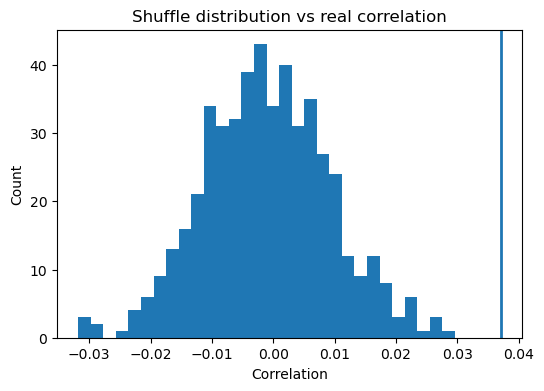

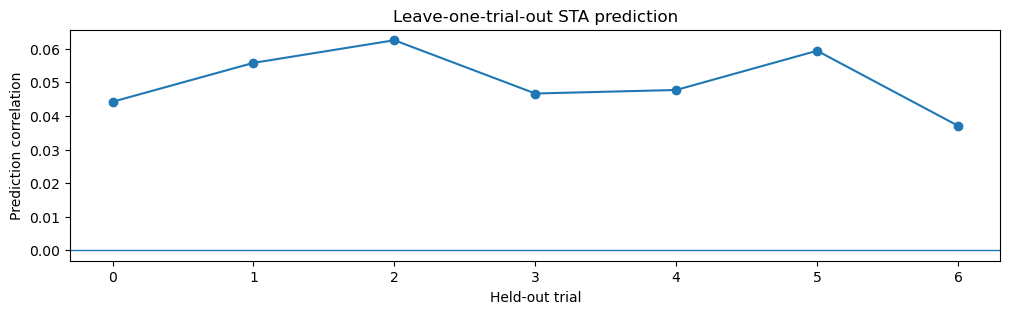

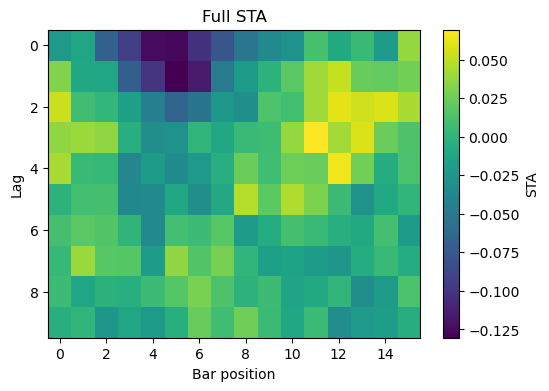

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d





def bin_spikes_to_frames(spike_times_sec, T, frame_rate, stim_onset_sec=0.0):
    spk_stim_sec = spike_times_sec - stim_onset_sec
    edges = np.arange(T + 1) / frame_rate
    counts, _ = np.histogram(spk_stim_sec, bins=edges)
    return counts


def smooth_frame_counts(counts, frame_rate, sigma_sec=0.05):
    sigma_frames = sigma_sec * frame_rate
    return gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_frames,
        mode="constant"
    ) * frame_rate


def safe_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return np.corrcoef(x, y)[0, 1]


# ---------- prepare stimulus ----------







# ---------- 2. split-half reliability ----------


split_corr = safe_corr(sta_a.ravel(), sta_b.ravel())

print("\nSplit-half reliability")
print("Spikes half A:", n_a)
print("Spikes half B:", n_b)
print("STA correlation:", split_corr)


# ---------- 3. leave-one-trial-out prediction ----------

loo_corrs = []

for test_idx in range(len(paths_linear_trial,)):
    train_files = [f for i, f in enumerate(paths_linear_trial,) if i != test_idx]
    test_file = paths_linear_trial[test_idx]

    sta_train, n_train = compute_sta(
        train_files,
        stim_centered,
        n_lags=n_lags,
        frame_rate=frame_rate,
        
    )

    r_est = compute_r_estimate(stim_centered, sta_train)

    _, spk_sec_test, _ = fget_spk_python(test_file)

    spike_counts = bin_spikes_to_frames(
        spk_sec_test,
        T=T,
        frame_rate=frame_rate,
        
    )

    rate_test = smooth_frame_counts(
        spike_counts,
        frame_rate=frame_rate,
        sigma_sec=0.05
    )

    corr = safe_corr(r_est, rate_test)
    loo_corrs.append(corr)

    print(f"\nHeld-out trial {test_idx + 1}")
    print("Train spikes:", n_train)
    print("Test spikes:", len(spk_sec_test))
    print("Prediction correlation:", corr)

loo_corrs = np.array(loo_corrs)

print("\nLeave-one-trial-out summary")
print("Mean correlation:", np.nanmean(loo_corrs))
print("Std correlation:", np.nanstd(loo_corrs))


# ---------- 4. shuffle control ----------

def shuffle_test(r_est, rate_test, n_shuffle=500):
    real_corr = safe_corr(r_est, rate_test)

    shuf_corrs = []
    for _ in range(n_shuffle):
        shift = np.random.randint(len(rate_test))
        rate_shuf = np.roll(rate_test, shift)
        shuf_corrs.append(safe_corr(r_est, rate_shuf))

    shuf_corrs = np.array(shuf_corrs)
    p_value = np.mean(shuf_corrs >= real_corr)

    return real_corr, shuf_corrs, p_value


# Test shuffle on the last held-out split, just as a quick diagnostic
real_corr, shuf_corrs, p_value = shuffle_test(r_est, rate_test, n_shuffle=500)

print("\nShuffle test on last held-out trial")
print("Real correlation:", real_corr)
print("Shuffle mean:", np.nanmean(shuf_corrs))
print("Shuffle std:", np.nanstd(shuf_corrs))
print("p-value:", p_value)


# ---------- 5. quick plots ----------

plt.figure(figsize=(6, 4))
plt.hist(shuf_corrs, bins=30)
plt.axvline(real_corr, linewidth=2)
plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title("Shuffle distribution vs real correlation")
plt.show()


plt.figure(figsize=(12, 3))
plt.plot(loo_corrs, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out STA prediction")
plt.show()


plt.figure(figsize=(6, 4))
plt.imshow(sta_all, aspect="auto", origin="upper")
plt.colorbar(label="STA")
plt.xlabel("Bar position")
plt.ylabel("Lag")
plt.title("Full STA")
plt.show()

## Optimal Kernel Estimation



In [ ]:
recording_duration = T / frame_rate
mean_firing_rate = n_spikes / recording_duration
stim_variance = np.var(msq1D_stim)

kernel = mean_firing_rate * sta / stim_variance
print(f'STA shape: {sta.shape}  (lags × bars)')
print(f'kernel shape:{kernel.shape}')

STA shape: (10, 16)  (lags × bars)
kernel shape:(10, 16)


In [ ]:
train_files = paths_linear_trial[:6]
test_files  = paths_linear_trial[6:]
sta_train,n_train = compute_sta(train_files, msq1D_stim, n_lags, frame_rate)



In [ ]:
kernel = mean_firing_rate * sta_train / stim_variance

In [ ]:
r_est=compute_r_estimate(msq1D_stim, kernel)

In [ ]:
r_est.shape

(32767,)

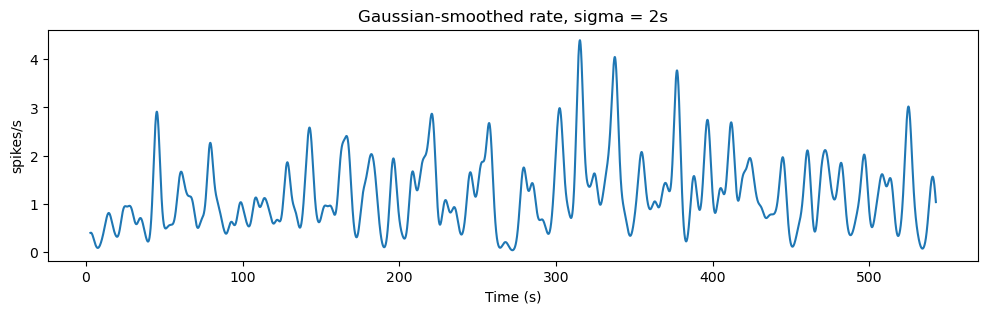

In [ ]:
import numpy as np
import matplotlib.pyplot as plt




# NOTE THIS IS FOR NOW JUST THE LAST TRIAL, SINCE THERE IS A FOR LOOP ABOVE  

for sigma in [ 2]:
    t, rate, _ = gaussian_rate_convolution(spike_times_sec, dt=0.001, sigma=sigma)

    plt.figure(figsize=(12, 3))
    plt.plot( t,rate)
    plt.title(f"Gaussian-smoothed rate, sigma = {sigma}s")
    plt.xlabel("Time (s)")
    plt.ylabel("spikes/s")
    plt.show()

In the 2005 Neuron paper, they again emphasize that ordinary STA is useful for simple/linear receptive fields but inadequate for complex cells

to correct the following 

In [ ]:
# to coorect


Total spikes used: 5639
Total spikes used for full STA: 5639

Total spikes used: 1873

Total spikes used: 3766

Split-half reliability
Spikes half A: 1873
Spikes half B: 3766
STA correlation: 0.7032817644366287

Total spikes used: 5056

Held-out trial 1
Train spikes: 5056
Test spikes: 583
Prediction correlation: 0.04421934722396835

Total spikes used: 4994

Held-out trial 2
Train spikes: 4994
Test spikes: 645
Prediction correlation: 0.05580973249949192

Total spikes used: 4994

Held-out trial 3
Train spikes: 4994
Test spikes: 645
Prediction correlation: 0.06255652060561967

Total spikes used: 4764

Held-out trial 4
Train spikes: 4764
Test spikes: 875
Prediction correlation: 0.046683067350382704

Total spikes used: 4837

Held-out trial 5
Train spikes: 4837
Test spikes: 802
Prediction correlation: 0.0477357167264035

Total spikes used: 4731

Held-out trial 6
Train spikes: 4731
Test spikes: 908
Prediction correlation: 0.0594198785397731

Total spikes used: 4458

Held-out trial 7
Train sp

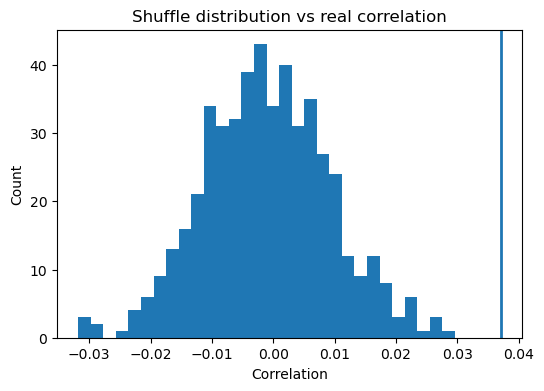

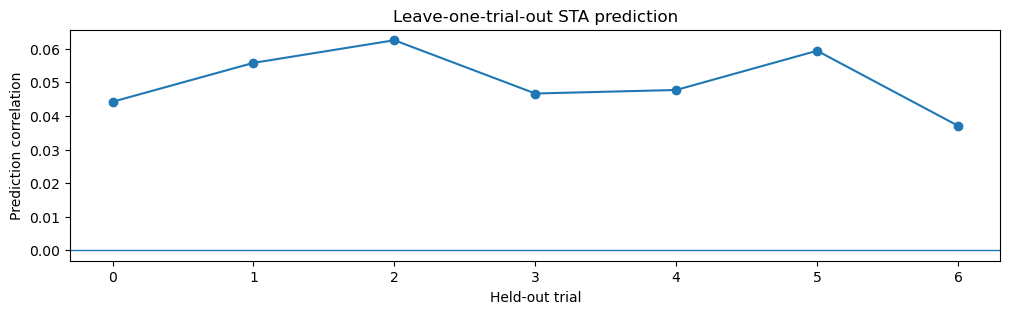

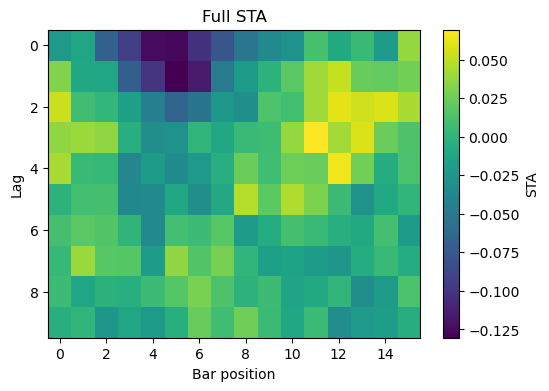

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d





def bin_spikes_to_frames(spike_times_sec, T, frame_rate, stim_onset_sec=0.0):
    spk_stim_sec = spike_times_sec - stim_onset_sec
    edges = np.arange(T + 1) / frame_rate
    counts, _ = np.histogram(spk_stim_sec, bins=edges)
    return counts


def smooth_frame_counts(counts, frame_rate, sigma_sec=0.05):
    sigma_frames = sigma_sec * frame_rate
    return gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_frames,
        mode="constant"
    ) * frame_rate


def safe_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return np.corrcoef(x, y)[0, 1]


# ---------- prepare stimulus ----------







# ---------- 2. split-half reliability ----------


split_corr = safe_corr(sta_a.ravel(), sta_b.ravel())

print("\nSplit-half reliability")
print("Spikes half A:", n_a)
print("Spikes half B:", n_b)
print("STA correlation:", split_corr)


# ---------- 3. leave-one-trial-out prediction ----------

loo_corrs = []

for test_idx in range(len(paths_linear_trial,)):
    train_files = [f for i, f in enumerate(paths_linear_trial,) if i != test_idx]
    test_file = paths_linear_trial[test_idx]

    sta_train, n_train = compute_sta(
        train_files,
        stim_centered,
        n_lags=n_lags,
        frame_rate=frame_rate,
        
    )

    r_est = compute_r_estimate(stim_centered, sta_train)

    _, spk_sec_test, _ = fget_spk_python(test_file)

    spike_counts = bin_spikes_to_frames(
        spk_sec_test,
        T=T,
        frame_rate=frame_rate,
        
    )

    rate_test = smooth_frame_counts(
        spike_counts,
        frame_rate=frame_rate,
        sigma_sec=0.05
    )

    corr = safe_corr(r_est, rate_test)
    loo_corrs.append(corr)

    print(f"\nHeld-out trial {test_idx + 1}")
    print("Train spikes:", n_train)
    print("Test spikes:", len(spk_sec_test))
    print("Prediction correlation:", corr)

loo_corrs = np.array(loo_corrs)

print("\nLeave-one-trial-out summary")
print("Mean correlation:", np.nanmean(loo_corrs))
print("Std correlation:", np.nanstd(loo_corrs))


# ---------- 4. shuffle control ----------

def shuffle_test(r_est, rate_test, n_shuffle=500):
    real_corr = safe_corr(r_est, rate_test)

    shuf_corrs = []
    for _ in range(n_shuffle):
        shift = np.random.randint(len(rate_test))
        rate_shuf = np.roll(rate_test, shift)
        shuf_corrs.append(safe_corr(r_est, rate_shuf))

    shuf_corrs = np.array(shuf_corrs)
    p_value = np.mean(shuf_corrs >= real_corr)

    return real_corr, shuf_corrs, p_value


# Test shuffle on the last held-out split, just as a quick diagnostic
real_corr, shuf_corrs, p_value = shuffle_test(r_est, rate_test, n_shuffle=500)

print("\nShuffle test on last held-out trial")
print("Real correlation:", real_corr)
print("Shuffle mean:", np.nanmean(shuf_corrs))
print("Shuffle std:", np.nanstd(shuf_corrs))
print("p-value:", p_value)


# ---------- 5. quick plots ----------

plt.figure(figsize=(6, 4))
plt.hist(shuf_corrs, bins=30)
plt.axvline(real_corr, linewidth=2)
plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title("Shuffle distribution vs real correlation")
plt.show()


plt.figure(figsize=(12, 3))
plt.plot(loo_corrs, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out STA prediction")
plt.show()


plt.figure(figsize=(6, 4))
plt.imshow(sta_all, aspect="auto", origin="upper")
plt.colorbar(label="STA")
plt.xlabel("Bar position")
plt.ylabel("Lag")
plt.title("Full STA")
plt.show()

## Standard method — STA as linear predictor

For an exactly white-noise stimulus the STA equals the Wiener filter — the optimal linear kernel. No whitening step is required. Prediction performance (Pearson r between the generator signal `g(t) = X(t)·w_STA` and the test-run smoothed firing rate) sets the baseline for linear models.